In [3]:
import pandas as pd
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "data" / "market_week_data.csv").exists()) 

df = pd.read_csv(ROOT / "data" / "market_week_data.csv")
df.head()

,market,week_index,week_start,sessions,fragrance_orders,fragrance_revenue,conversion_rate,average_order_value,revenue_per_session,paid_media_index,promo_intensity,new_visitor_share,pilot_market,post_launch,digital_feature_available,weeks_from_launch
0,Australia,0,2025-01-06,69314,1870,147050.31,0.026979,78.64,2.1215,96.81,0.2081,0.3308,0,0,0,-65
1,Australia,1,2025-01-13,71010,2011,159108.26,0.028320,79.12,2.2406,100.78,0.2142,0.3870,0,0,0,-64
2,Australia,2,2025-01-20,71268,1954,150249.86,0.027418,76.89,2.1082,89.21,0.2005,0.3705,0,0,0,-63
3,Australia,3,2025-01-27,67993,1632,128219.61,0.024002,78.57,1.8858,104.77,0.2123,0.3519,0,0,0,-62
4,Australia,4,2025-02-03,68280,1952,161268.21,0.028588,82.62,2.3619,101.49,0.1982,0.3558,0,0,0,-61


In [4]:
launch_week = df.loc[df["post_launch"] == 1, "week_index"].min()

pre = df[df["week_index"] < launch_week].copy()

print("US launch week:", launch_week)
print("Pre-treatment weeks:", pre["week_index"].min(), "to", pre["week_index"].max())

US launch week: 65
Pre-treatment weeks: 0 to 64


In [ ]:
# To compare pre-treatment trends between the US and each candidate market
us = pre[pre["market"] == "United States"].set_index("week_index")

results = []

for market in pre["market"].unique():
    if market == "United States":
        continue
    
    other = pre[pre["market"] == market].set_index("week_index")
    
    comparison = us["revenue_per_session"].to_frame("us_rps").join(
        other["revenue_per_session"].to_frame("market_rps"),
        how="inner"
    )
    
    correlation = comparison["us_rps"].corr(comparison["market_rps"])
    rmse = ((comparison["us_rps"] - comparison["market_rps"]) ** 2).mean() ** 0.5
    
    results.append({
        "market": market,
        "correlation_with_US": correlation,
        "pre_period_RMSE": rmse
    })

comparison_results = pd.DataFrame(results).sort_values(
    "correlation_with_US", ascending=False
)

comparison_results

,market,correlation_with_US,pre_period_RMSE
1,Canada,0.859585,0.259530
5,United Kingdom,0.636924,0.296926
3,Germany,0.632298,0.396341
4,Japan,0.554871,0.318758
2,France,0.549898,0.401557
0,Australia,-0.444863,0.651369


In [6]:
# To compare pre-treatment trends between the US and each candidate market

slopes = []

for market in pre["market"].unique():
    market_data = pre[pre["market"] == market]
    
    slope = market_data["revenue_per_session"].cov(
        market_data["week_index"]
    ) / market_data["week_index"].var()
    
    slopes.append({
        "market": market,
        "pre_treatment_slope": slope
    })

slope_results = pd.DataFrame(slopes).sort_values(
    "pre_treatment_slope",
    ascending=False
)

slope_results

,market,pre_treatment_slope
5,United Kingdom,0.008441
3,Germany,0.003168
4,Japan,0.003152
6,United States,0.002722
2,France,0.002685
1,Canada,0.001741
0,Australia,0.000672


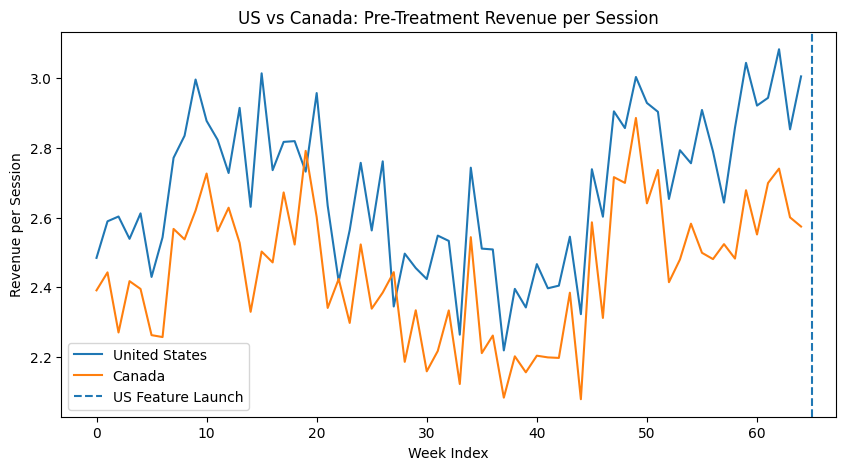

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for market in ["United States", "Canada"]:
    market_data = pre[pre["market"] == market]
    plt.plot(
        market_data["week_index"],
        market_data["revenue_per_session"],
        label=market
    )

plt.axvline(launch_week, linestyle="--", label="US Feature Launch")

plt.xlabel("Week Index")
plt.ylabel("Revenue per Session")
plt.title("US vs Canada: Pre-Treatment Revenue per Session")
plt.legend()
plt.show()

In [9]:
# Now we compare each market's pre-treatment trend to the US trend

us_slope = slope_results.loc[
    slope_results["market"] == "United States",
    "pre_treatment_slope"
].iloc[0]

slope_results["difference_from_US"] = (
    slope_results["pre_treatment_slope"] - us_slope
).abs()

slope_results.sort_values("difference_from_US")

,market,pre_treatment_slope,difference_from_US
6,United States,0.002722,0.000000
2,France,0.002685,0.000037
4,Japan,0.003152,0.000430
3,Germany,0.003168,0.000446
1,Canada,0.001741,0.000981
0,Australia,0.000672,0.002050
5,United Kingdom,0.008441,0.005719


In [10]:
#overall pre-treatment similarity ranking
final_comparison = comparison_results.merge(
    slope_results[["market", "difference_from_US"]],
    on="market"
)

final_comparison["correlation_rank"] = (
    final_comparison["correlation_with_US"]
    .rank(ascending=False)
)

final_comparison["RMSE_rank"] = (
    final_comparison["pre_period_RMSE"]
    .rank(ascending=True)
)

final_comparison["slope_rank"] = (
    final_comparison["difference_from_US"]
    .rank(ascending=True)
)

final_comparison["average_rank"] = final_comparison[
    ["correlation_rank", "RMSE_rank", "slope_rank"]
].mean(axis=1)

final_comparison.sort_values("average_rank")

,market,correlation_with_US,pre_period_RMSE,difference_from_US,correlation_rank,RMSE_rank,slope_rank,average_rank
0,Canada,0.859585,0.259530,0.000981,1.0,1.0,4.0,2.000000
3,Japan,0.554871,0.318758,0.000430,4.0,3.0,2.0,3.000000
1,United Kingdom,0.636924,0.296926,0.005719,2.0,2.0,6.0,3.333333
2,Germany,0.632298,0.396341,0.000446,3.0,4.0,3.0,3.333333
4,France,0.549898,0.401557,0.000037,5.0,5.0,1.0,3.666667
5,Australia,-0.444863,0.651369,0.002050,6.0,6.0,5.0,5.666667


## Counterfactual Market Selection

The United States is the pilot market, with the digital feature launching at week 65 (April 6, 2026). To select a counterfactual market, I compared the pre-treatment behavior of each non-US market using revenue per session.

Canada was selected as the best counterfactual market. It had the highest pre-treatment correlation with the US (0.8596) and the lowest pre-treatment RMSE (0.2595), indicating that its revenue-per-session movements and levels were most similar to the US before the feature launch. Canada also had a reasonably similar pre-treatment trend, with a slope of 0.001741 compared with 0.002722 for the US.

Although France had the closest individual pre-treatment slope to the US, its correlation (0.5499) and RMSE (0.4016) were substantially weaker. Therefore, considering correlation, level similarity, and trend similarity together, Canada provides the strongest overall pre-treatment match and is selected as the US counterfactual market.

This selection is based on pre-treatment similarity and should be interpreted as evidence supporting Canada as a plausible counterfactual, rather than proof that the markets would have followed identical post-treatment trajectories.